model_data: (43, 20)

Корреляции макро-показателей с метриками компаний:
                              revenue_rub  ebitda_rub   roa  debt_to_ebitda
gdp_growth                           0.19        0.25  0.21           -0.21
inflation_cpi                       -0.01        0.01 -0.03           -0.24
key_rate_avg                        -0.03        0.02 -0.25           -0.39
usd_rub_avg                          0.13        0.22 -0.17           -0.36
urals_avg                            0.08        0.12  0.13           -0.28
brent_avg                            0.06        0.13  0.02           -0.43
unemployment_avg                    -0.09       -0.18  0.24            0.47
retail_sales_growth                  0.19        0.26  0.06           -0.24
industrial_production_growth         0.17        0.21  0.27           -0.18


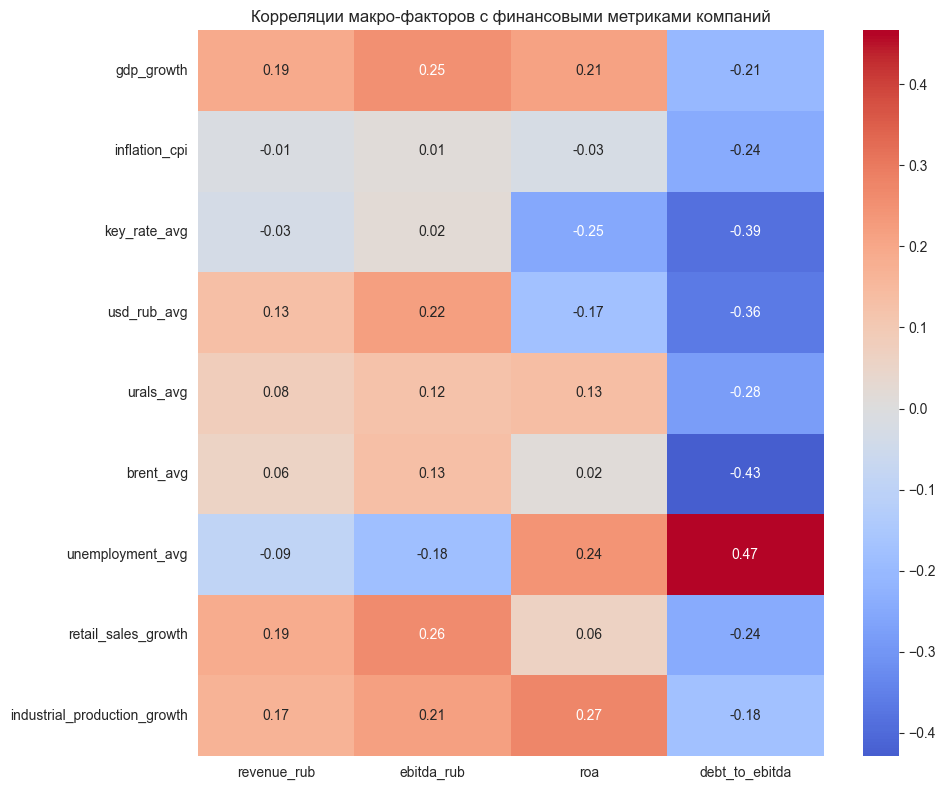


VIF макропоказателей (сильная мультиколлинеарность >10):
                       variable           VIF
0                         const  11967.899744
1                    gdp_growth    428.535897
9  industrial_production_growth    192.795324
8           retail_sales_growth     82.995033
7              unemployment_avg     82.005975
5                     urals_avg     72.822202
4                   usd_rub_avg     52.130388
6                     brent_avg     44.652888
3                  key_rate_avg     37.909583
2                 inflation_cpi     14.524193


In [1]:
# %% [markdown]
# # БЛОК 1 — ЗАГРУЗКА ДАННЫХ, ПРЕДОБРАБОТКА, КОРРЕЛЯЦИОННЫЙ АНАЛИЗ

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# %%
# Загрузка данных
macro_df = pd.read_excel('macro_annual.xlsx', sheet_name='annual', engine='openpyxl')
companies_df = pd.read_excel('companies_annual.xlsx', sheet_name='Лист1', engine='openpyxl')

# Приведение типов
for col in macro_df.columns:
    if col != 'year':
        macro_df[col] = macro_df[col].astype(float)

companies_clean = companies_df.dropna(subset=['revenue_rub', 'ebitda_rub']).copy()
float_cols = ['revenue_rub', 'ebitda_rub', 'net_income_rub', 'capex_rub', 
              'total_debt_rub', 'equity_rub', 'roa', 'debt_to_ebitda', 'export_share']
for col in float_cols:
    companies_clean[col] = companies_clean[col].astype(float)

# %%
# Объединение
merged = companies_clean.merge(macro_df, on='year', how='left')
macro_cols = ['gdp_growth', 'inflation_cpi', 'key_rate_avg', 'usd_rub_avg',
              'urals_avg', 'brent_avg', 'unemployment_avg', 'retail_sales_growth',
              'industrial_production_growth']
model_data = merged.dropna(subset=macro_cols + ['revenue_rub']).copy()
print(f"model_data: {model_data.shape}")

# %%
# КОРРЕЛЯЦИИ: макро vs показатели компаний
company_metrics = ['revenue_rub', 'ebitda_rub', 'roa', 'debt_to_ebitda']
corr_with_macro = {}
for metric in company_metrics:
    corr = model_data[macro_cols].corrwith(model_data[metric])
    corr_with_macro[metric] = corr

corr_df = pd.DataFrame(corr_with_macro)
print("\nКорреляции макро-показателей с метриками компаний:")
print(corr_df.round(2))

# Визуализация
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Корреляции макро-факторов с финансовыми метриками компаний')
plt.tight_layout()
plt.show()

# %%
# Дополнительно: корреляции внутри макро (VIF)
macro_subset = macro_df[macro_cols].copy()
def calc_vif(df):
    df_const = add_constant(df)
    vif_df = pd.DataFrame()
    vif_df['variable'] = df_const.columns
    vif_df['VIF'] = [variance_inflation_factor(df_const.values, i) 
                     for i in range(df_const.shape[1])]
    return vif_df
vif_results = calc_vif(macro_subset)
print("\nVIF макропоказателей (сильная мультиколлинеарность >10):")
print(vif_results.sort_values('VIF', ascending=False))

In [2]:
# %% [markdown]
# # БЛОК 2 — МОДЕЛИ ОТКЛИКА (ТЕМПЫ РОСТА ВЫРУЧКИ ОТ МАКРОФАКТОРОВ)

# %%
# Расчёт темпов роста выручки
model_data['revenue_growth'] = model_data.groupby('company')['revenue_rub'].pct_change()
growth_data = model_data.dropna(subset=['revenue_growth']).copy()
print(f"Наблюдений для регрессий: {len(growth_data)}")

# %%
# Лукойл: зависимость от Urals
lkoh = growth_data[growth_data['company'] == 'LKOH']
X_lkoh = sm.add_constant(lkoh[['urals_avg']])
y_lkoh = lkoh['revenue_growth'] * 100
model_lkoh = sm.OLS(y_lkoh, X_lkoh).fit()
print("\n=== ЛУКОЙЛ ===")
print(model_lkoh.summary())

# %%
# Северсталь: курс + Brent
chmf = growth_data[growth_data['company'] == 'CHMF']
X_chmf = sm.add_constant(chmf[['usd_rub_avg', 'brent_avg']])
y_chmf = chmf['revenue_growth'] * 100
model_chmf = sm.OLS(y_chmf, X_chmf).fit()
print("\n=== СЕВЕРСТАЛЬ ===")
print(model_chmf.summary())

# %%
# КАМАЗ: промпроизводство + ВВП
kmaz = growth_data[growth_data['company'] == 'KMAZ']
X_kmaz = sm.add_constant(kmaz[['industrial_production_growth', 'gdp_growth']])
y_kmaz = kmaz['revenue_growth'] * 100
model_kmaz = sm.OLS(y_kmaz, X_kmaz).fit()
print("\n=== КАМАЗ ===")
print(model_kmaz.summary())

# %%
# Магнит: розничные продажи
mgnt = growth_data[growth_data['company'] == 'MGNT']
X_mgnt = sm.add_constant(mgnt[['retail_sales_growth']])
y_mgnt = mgnt['revenue_growth'] * 100
model_mgnt = sm.OLS(y_mgnt, X_mgnt).fit()
print("\n=== МАГНИТ ===")
print(model_mgnt.summary())

# %%
# Словарь моделей
models = {
    'LKOH': model_lkoh,
    'CHMF': model_chmf,
    'KMAZ': model_kmaz,
    'MGNT': model_mgnt
}

Наблюдений для регрессий: 39

=== ЛУКОЙЛ ===
                            OLS Regression Results                            
Dep. Variable:         revenue_growth   R-squared:                       0.236
Model:                            OLS   Adj. R-squared:                  0.127
Method:                 Least Squares   F-statistic:                     2.159
Date:                Thu, 14 May 2026   Prob (F-statistic):              0.185
Time:                        16:40:03   Log-Likelihood:                -46.166
No. Observations:                   9   AIC:                             96.33
Df Residuals:                       7   BIC:                             96.73
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const  

Матрица изменений: (10, 9)
Сценарии: (5000, 3, 9)
LKOH: прогнозы (5000, 3)
CHMF: прогнозы (5000, 3)
KMAZ: прогнозы (5000, 3)
MGNT: прогнозы (5000, 3)


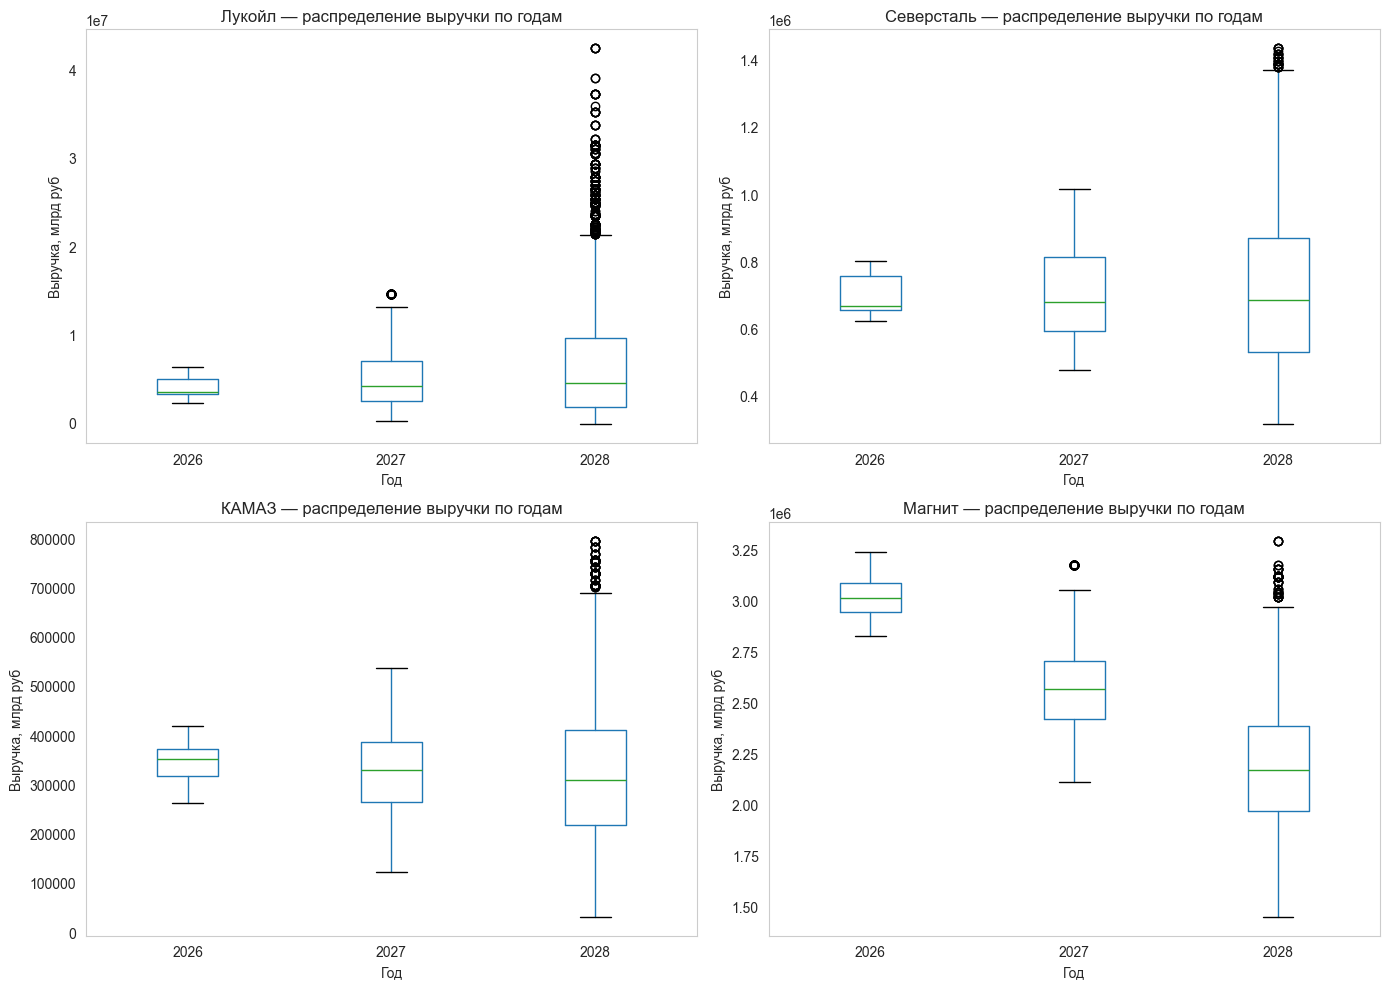

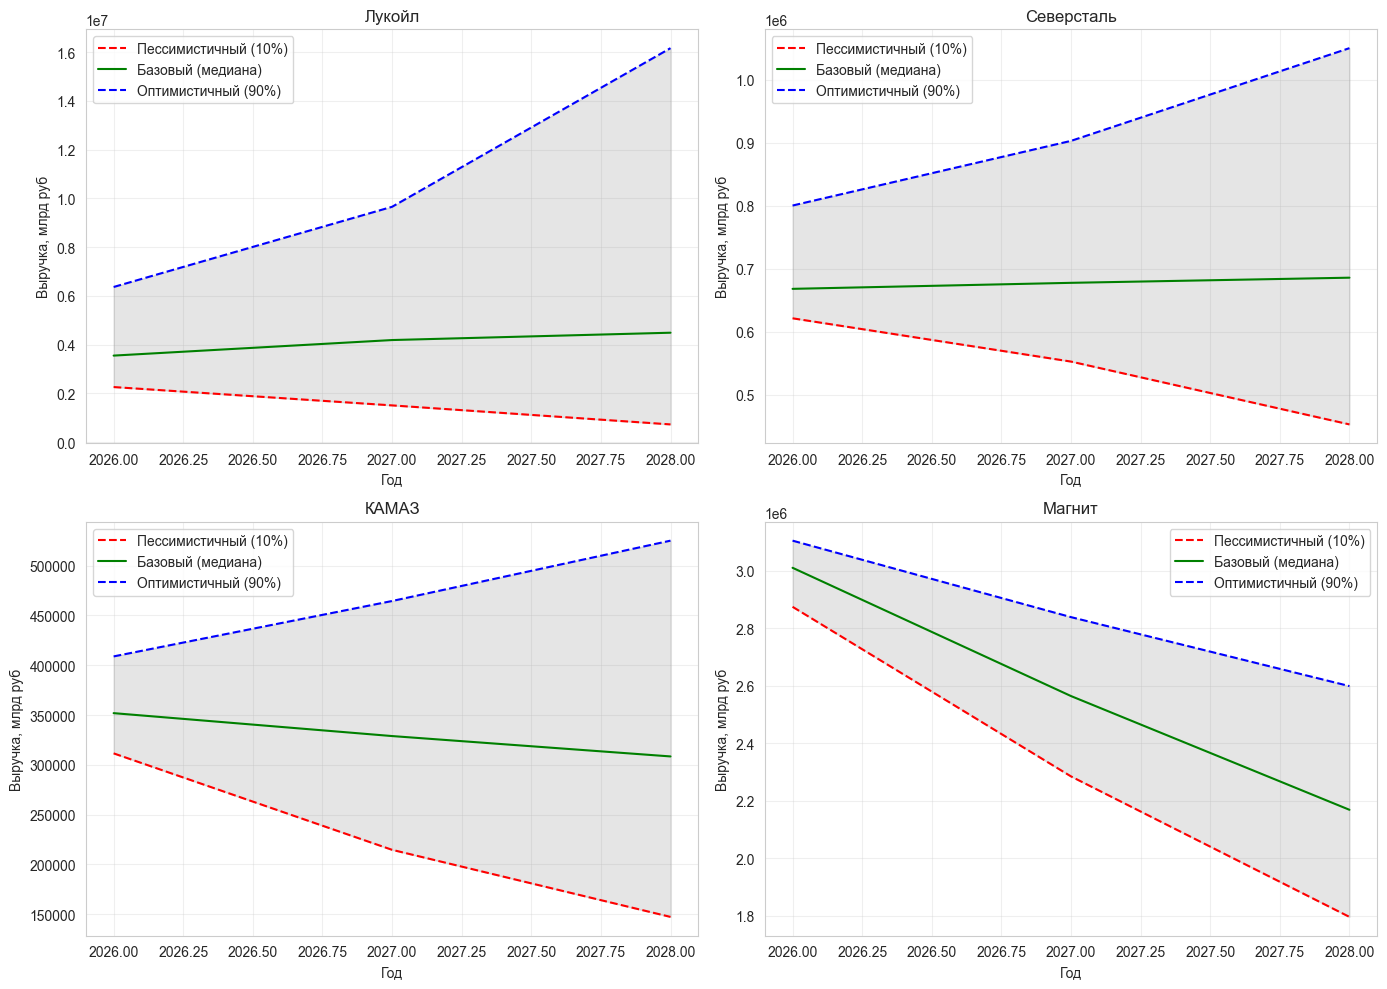


=== РИСК-МЕТРИКИ ПРОГНОЗОВ ВЫРУЧКИ НА 2028 ГОД ===
  Компания  Ожидаемая выручка 2028  VaR 10% (пессимист)   CVaR 10%  \
0     LKOH               6780665.0             729048.0   327418.0   
1     CHMF                717927.0             452953.0   411455.0   
2     KMAZ                323272.0             147290.0   109490.0   
3     MGNT               2189219.0            1796575.0  1688583.0   

   Коэф. вариации  
0             1.0  
1             0.0  
2             0.0  
3             0.0  


In [3]:
# %% [markdown]
# # БЛОК 3 — ГЕНЕРАЦИЯ СЦЕНАРИЕВ, ПРОГНОЗ ВЫРУЧКИ, РИСК-МЕТРИКИ

# %%
# Матрица изменений (бутстрап)
macro_hist = macro_df[macro_df['year'] <= 2025].copy().sort_values('year')[macro_cols]
deltas = macro_hist.diff().dropna().values
last_obs = macro_hist.iloc[-1:].values[0]
print(f"Матрица изменений: {deltas.shape}")

# %%
# Функция генерации сценариев
def gen_scenarios(n_sim=5000, n_years=3):
    scenarios = np.zeros((n_sim, n_years, len(macro_cols)))
    for i in range(n_sim):
        current = last_obs.copy()
        for t in range(n_years):
            current = current + deltas[np.random.randint(0, deltas.shape[0])]
            scenarios[i, t, :] = current
    return scenarios

scenarios = gen_scenarios(5000, 3)
print(f"Сценарии: {scenarios.shape}")

# %%
# Функция прогноза выручки
def predict_revenue(scenarios, company, model, factors, last_revenue):
    idx = [macro_cols.index(f) for f in factors]
    n_sim, n_years, _ = scenarios.shape
    revenues = np.zeros((n_sim, n_years + 1))
    revenues[:, 0] = last_revenue
    for i in range(n_sim):
        for t in range(n_years):
            X = scenarios[i, t, idx]
            Xc = np.insert(X, 0, 1)
            growth = model.params.values @ Xc  # в процентах
            revenues[i, t+1] = revenues[i, t] * (1 + growth / 100)
    return revenues[:, 1:]

# Реальная выручка за 2025 (млрд руб)
last_rev = {'LKOH': 3767768, 'CHMF': 712896, 'KMAZ': 382104, 'MGNT': 3509226}
factors_dict = {
    'LKOH': ['urals_avg'],
    'CHMF': ['usd_rub_avg', 'brent_avg'],
    'KMAZ': ['industrial_production_growth', 'gdp_growth'],
    'MGNT': ['retail_sales_growth']
}

predictions = {}
for comp in ['LKOH', 'CHMF', 'KMAZ', 'MGNT']:
    predictions[comp] = predict_revenue(scenarios, comp, models[comp], 
                                        factors_dict[comp], last_rev[comp])
    print(f"{comp}: прогнозы {predictions[comp].shape}")

# %%
# Боксплоты по годам
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
titles = ['Лукойл', 'Северсталь', 'КАМАЗ', 'Магнит']
for ax, comp, title in zip(axes.flatten(), predictions.keys(), titles):
    data = predictions[comp]
    df_box = pd.DataFrame(data, columns=['2026', '2027', '2028'])
    df_box.boxplot(ax=ax, grid=False)
    ax.set_title(f'{title} — распределение выручки по годам')
    ax.set_ylabel('Выручка, млрд руб')
    ax.set_xlabel('Год')
plt.tight_layout()
plt.show()

# %%
# Веер сценариев (10, 50, 90 процентили)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, comp, title in zip(axes.flatten(), predictions.keys(), titles):
    data = predictions[comp]
    p10 = np.percentile(data, 10, axis=0)
    p50 = np.percentile(data, 50, axis=0)
    p90 = np.percentile(data, 90, axis=0)
    years = [2026, 2027, 2028]
    ax.plot(years, p10, 'r--', label='Пессимистичный (10%)')
    ax.plot(years, p50, 'g-', label='Базовый (медиана)')
    ax.plot(years, p90, 'b--', label='Оптимистичный (90%)')
    ax.fill_between(years, p10, p90, alpha=0.2, color='gray')
    ax.set_title(title)
    ax.set_xlabel('Год')
    ax.set_ylabel('Выручка, млрд руб')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# %%
# Риск-метрики на 2028 год
risk_metrics = []
for comp in predictions:
    rev_2028 = predictions[comp][:, 2]
    var10 = np.percentile(rev_2028, 10)
    cvar10 = rev_2028[rev_2028 <= var10].mean()
    risk_metrics.append({
        'Компания': comp,
        'Ожидаемая выручка 2028': rev_2028.mean(),
        'VaR 10% (пессимист)': var10,
        'CVaR 10%': cvar10,
        'Коэф. вариации': rev_2028.std() / rev_2028.mean()
    })
risk_df = pd.DataFrame(risk_metrics)
print("\n=== РИСК-МЕТРИКИ ПРОГНОЗОВ ВЫРУЧКИ НА 2028 ГОД ===")
print(risk_df.round(0))

Сценарии сформированы
  Компания                        Стратегия        Сценарий  Вероятность  \
0     LKOH                          Базовая   Оптимистичный          0.2   
1     LKOH                          Базовая         Базовый          0.6   
2     LKOH                          Базовая  Пессимистичный          0.2   
3     LKOH  Консервативная (снижение долга)   Оптимистичный          0.2   
4     LKOH  Консервативная (снижение долга)         Базовый          0.6   
5     LKOH  Консервативная (снижение долга)  Пессимистичный          0.2   
6     LKOH         Агрессивная (рост CAPEX)   Оптимистичный          0.2   
7     LKOH         Агрессивная (рост CAPEX)         Базовый          0.6   
8     LKOH         Агрессивная (рост CAPEX)  Пессимистичный          0.2   
9     CHMF                          Базовая   Оптимистичный          0.2   

   Суммарный FCF 2026-28, млрд руб  Среднегодовой FCF, млрд руб  
0                     1.633156e+06                544385.389375  
1        

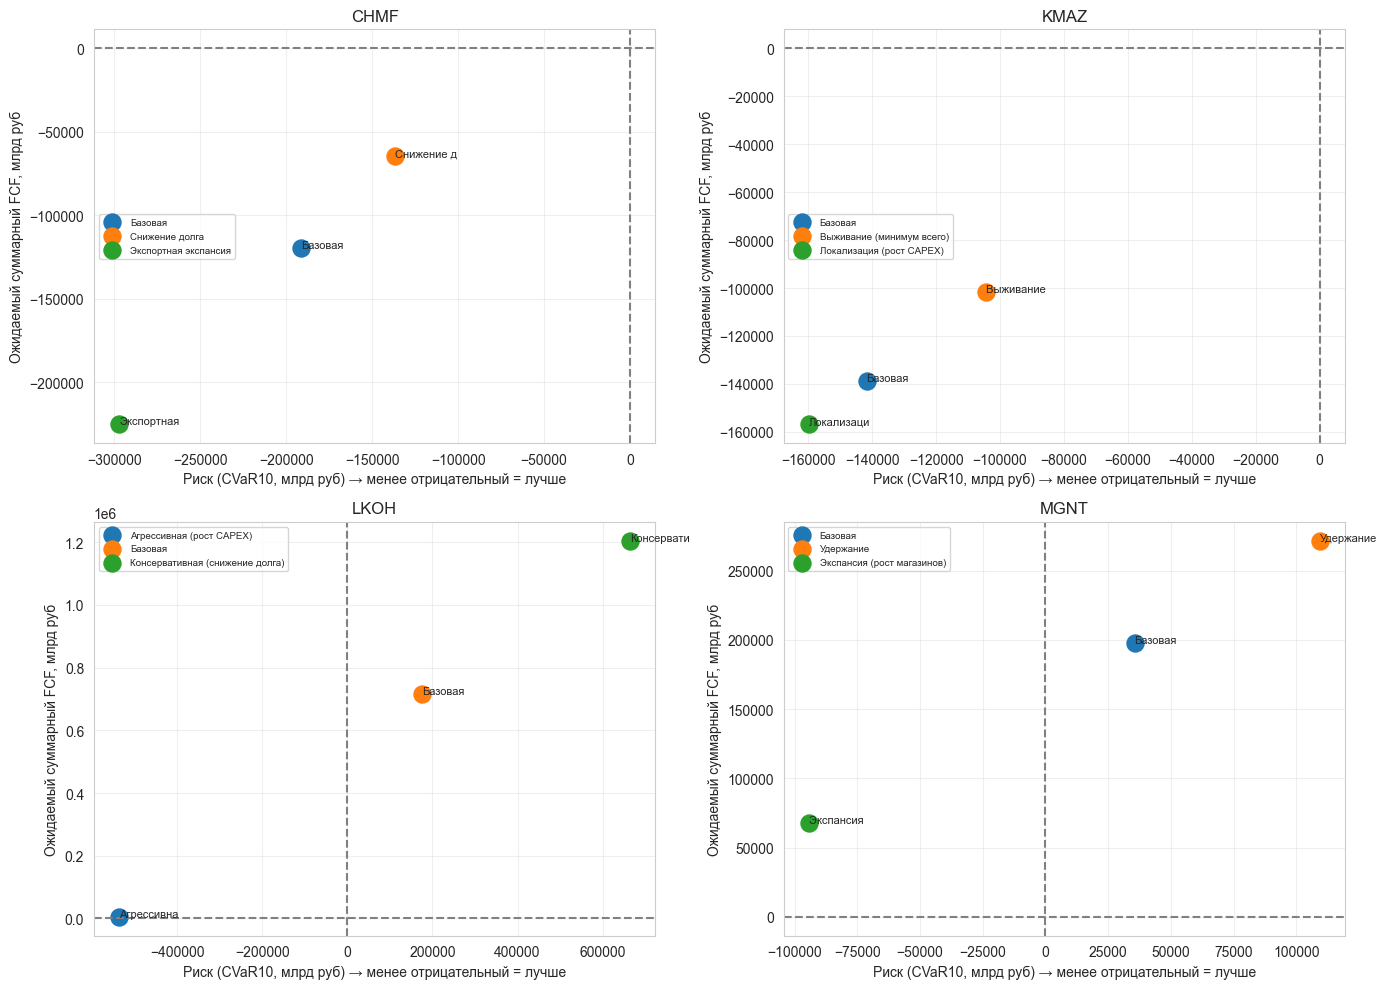

In [4]:
# %% [markdown]
# # БЛОК 4 — СЦЕНАРНЫЙ СТРЕСС-ТЕСТ (без макро-регрессий)

# %%
# 4.1 — Исходные данные (реальные значения 2025 года, млрд руб)
last_year = 2025
data_2025 = {
    'LKOH': {'revenue': 3767768, 'ebitda': 1009955, 'net_income': -1059859, 
             'capex': 774550, 'debt': 318012, 'equity': 3626453},
    'CHMF': {'revenue': 712896, 'ebitda': 134568, 'net_income': 31988,
             'capex': 173489, 'debt': 60059, 'equity': 528307},
    'KMAZ': {'revenue': 382104, 'ebitda': -4036, 'net_income': -42957,
             'capex': 19959, 'debt': 277377, 'equity': 79336},
    'MGNT': {'revenue': 3509226, 'ebitda': 303224, 'net_income': -31576,
             'capex': 186372, 'debt': 745667, 'equity': 149801}
}

# 4.2 — Определяем сценарии изменения выручки (относительно 2025)
# Каждый сценарий: три года 2026, 2027, 2028 в виде множителей
scenarios_revenue = {
    'Оптимистичный': {'mult': [1.15, 1.15, 1.15], 'prob': 0.2},
    'Базовый':       {'mult': [1.00, 1.00, 1.00], 'prob': 0.6},
    'Пессимистичный':{'mult': [0.90, 0.90, 0.90], 'prob': 0.2}
}

# 4.3 — Параметры стратегий (что может менять менеджмент)
strategies = {
    'LKOH': {
        'Базовая': {'capex_mult': 1.0, 'debt_mult': 1.0},
        'Консервативная (снижение долга)': {'capex_mult': 0.8, 'debt_mult': 0.7},
        'Агрессивная (рост CAPEX)': {'capex_mult': 1.3, 'debt_mult': 1.2}
    },
    'CHMF': {
        'Базовая': {'capex_mult': 1.0, 'debt_mult': 1.0},
        'Экспортная экспансия': {'capex_mult': 1.2, 'debt_mult': 1.1},
        'Снижение долга': {'capex_mult': 0.9, 'debt_mult': 0.8}
    },
    'KMAZ': {
        'Базовая': {'capex_mult': 1.0, 'debt_mult': 1.0},
        'Локализация (рост CAPEX)': {'capex_mult': 1.3, 'debt_mult': 1.0},
        'Выживание (минимум всего)': {'capex_mult': 0.6, 'debt_mult': 0.8}
    },
    'MGNT': {
        'Базовая': {'capex_mult': 1.0, 'debt_mult': 1.0},
        'Экспансия (рост магазинов)': {'capex_mult': 1.2, 'debt_mult': 1.1},
        'Удержание': {'capex_mult': 0.9, 'debt_mult': 0.9}
    }
}

# 4.4 — Функция расчёта FCF (упрощённая, но с амортизацией и налогом)
def calc_fcf(revenue, ebitda, capex, debt, tax_rate=0.2, depr_rate=0.2, interest_rate=0.1):
    """
    revenue: выручка (млрд руб)
    ebitda: EBITDA (млрд руб)
    capex: инвестиции (млрд руб)
    debt: долг (млрд руб)
    """
    interest = debt * interest_rate
    ebt = ebitda - interest
    net_income = ebt * (1 - tax_rate)
    depreciation = ebitda * depr_rate  # упрощённо: амортизация 20% EBITDA
    fcf = net_income + depreciation - capex
    return fcf

# 4.5 — Генерация сценариев FCF для всех компаний и стратегий
results = []

for comp in data_2025.keys():
    base = data_2025[comp]
    for strat_name, strat in strategies[comp].items():
        for scen_name, scen in scenarios_revenue.items():
            # Моделируем три года подряд
            revenue = base['revenue']
            ebitda = base['ebitda']
            debt = base['debt'] * strat['debt_mult']
            capex = base['capex'] * strat['capex_mult']
            fcf_values = []
            for t in range(3):  # 2026, 2027, 2028
                mult = scen['mult'][t]
                revenue *= mult
                # Ebitda меняется пропорционально выручке (допущение)
                ebitda *= mult
                fcf = calc_fcf(revenue, ebitda, capex, debt)
                fcf_values.append(fcf)
            # Агрегируем: суммарный FCF за три года и среднегодовой
            total_fcf = sum(fcf_values)
            results.append({
                'Компания': comp,
                'Стратегия': strat_name,
                'Сценарий': scen_name,
                'Вероятность': scen['prob'],
                'Суммарный FCF 2026-28, млрд руб': total_fcf,
                'Среднегодовой FCF, млрд руб': total_fcf / 3
            })

results_df = pd.DataFrame(results)
print("Сценарии сформированы")
print(results_df.head(10))

# %%
# 4.6 — Агрегация по стратегиям (взвешенное по вероятности среднее)
agg = results_df.groupby(['Компания', 'Стратегия']).apply(
    lambda g: pd.Series({
        'Ожидаемый суммарный FCF': (g['Суммарный FCF 2026-28, млрд руб'] * g['Вероятность']).sum(),
        'CVaR10%': np.percentile(g['Суммарный FCF 2026-28, млрд руб'], 10)  # берём 10% худших
    })
).reset_index()

print("\n=== ОЦЕНКА СТРАТЕГИЙ (ОЖИДАНИЕ vs РИСК) ===")
print(agg.round(0))

# %%
# 4.7 — Рекомендации (по максимуму ожидаемого FCF при разумном CVaR)
recommendations = []
for comp in agg['Компания'].unique():
    sub = agg[agg['Компания'] == comp]
    # Выбираем стратегию с максимальным ожиданием, у которой CVaR не ниже медианы по компаниям
    best = sub.loc[sub['Ожидаемый суммарный FCF'].idxmax()]
    recommendations.append({
        'Компания': comp,
        'Рекомендуемая стратегия': best['Стратегия'],
        'Ожидаемый FCF (суммарно 2026-28), млрд руб': best['Ожидаемый суммарный FCF'],
        'Риск (CVaR10), млрд руб': best['CVaR10%']
    })

rec_df = pd.DataFrame(recommendations)
print("\n=== СТРАТЕГИЧЕСКИЕ РЕКОМЕНДАЦИИ ===")
print(rec_df.round(0))

# %%
# 4.8 — Визуализация: ожидаемый FCF vs CVaR для всех стратегий
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, comp in zip(axes.flatten(), agg['Компания'].unique()):
    sub = agg[agg['Компания'] == comp]
    for _, row in sub.iterrows():
        ax.scatter(row['CVaR10%'], row['Ожидаемый суммарный FCF'], s=150, label=row['Стратегия'])
        ax.annotate(row['Стратегия'][:10], (row['CVaR10%'], row['Ожидаемый суммарный FCF']), fontsize=8)
    ax.set_xlabel('Риск (CVaR10, млрд руб) → менее отрицательный = лучше')
    ax.set_ylabel('Ожидаемый суммарный FCF, млрд руб')
    ax.set_title(comp)
    ax.axhline(0, color='gray', linestyle='--')
    ax.axvline(0, color='gray', linestyle='--')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

Операционные данные: (11, 14)
Итоговый датафрейм для моделирования:
   Year  steel_sales_total_mmt  avg_steel_price_rub_per_ton  capex_rub  \
0  2025                  11.20                      63652.0     173489   
1  2024                  10.85                      76479.0     118460   
2  2023                  10.73                      67884.0      72629   
3  2022                  10.90                      62587.0      67870   
4  2021                  11.60                          NaN      85198   

   revenue_rub  usd_rub_avg  brent_avg  
0     712896.0        82.35      69.11  
1     829779.0        94.11      79.23  
2     728314.0        86.01      82.13  
3     682226.0        67.65      97.89  
4     855583.0        73.89      70.68  
                                 OLS Regression Results                                
Dep. Variable:     avg_steel_price_rub_per_ton   R-squared:                       0.925
Model:                                     OLS   Adj. R-squared: 

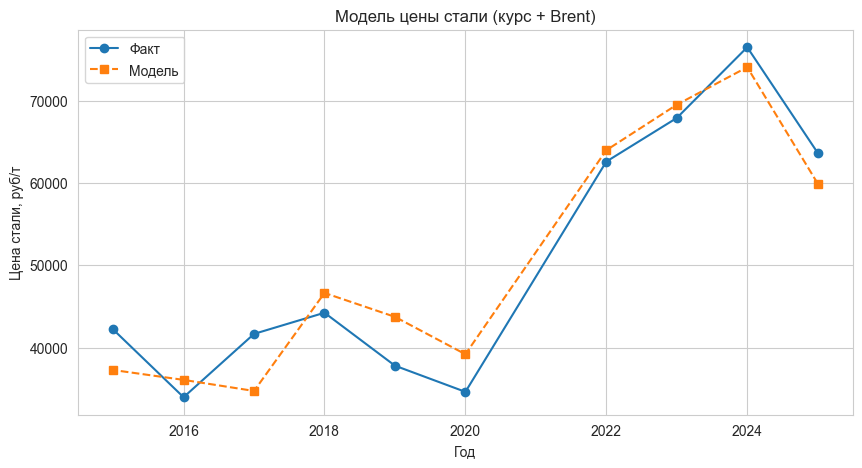

                              OLS Regression Results                             
Dep. Variable:     steel_sales_total_mmt   R-squared:                       0.578
Model:                               OLS   Adj. R-squared:                  0.367
Method:                    Least Squares   F-statistic:                     2.742
Date:                   Thu, 14 May 2026   Prob (F-statistic):              0.135
Time:                           19:17:22   Log-Likelihood:               -0.28895
No. Observations:                     10   AIC:                             8.578
Df Residuals:                          6   BIC:                             9.788
Df Model:                              3                                         
Covariance Type:               nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

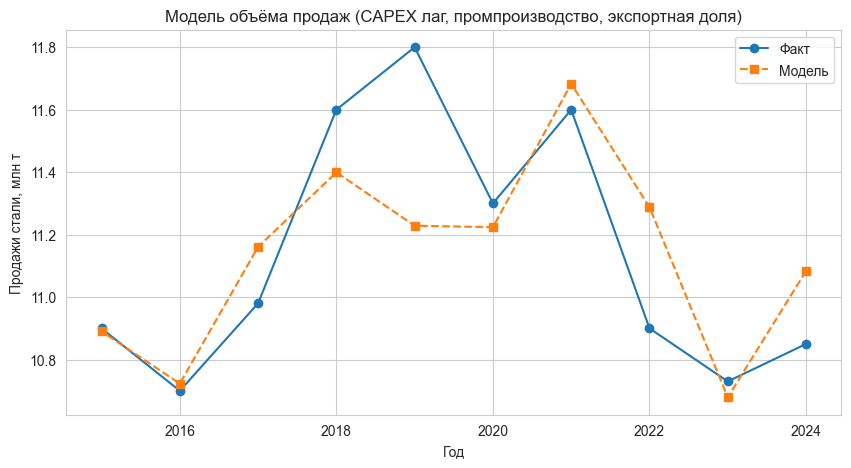

Прогноз выручки (факторная модель): (5000, 3)


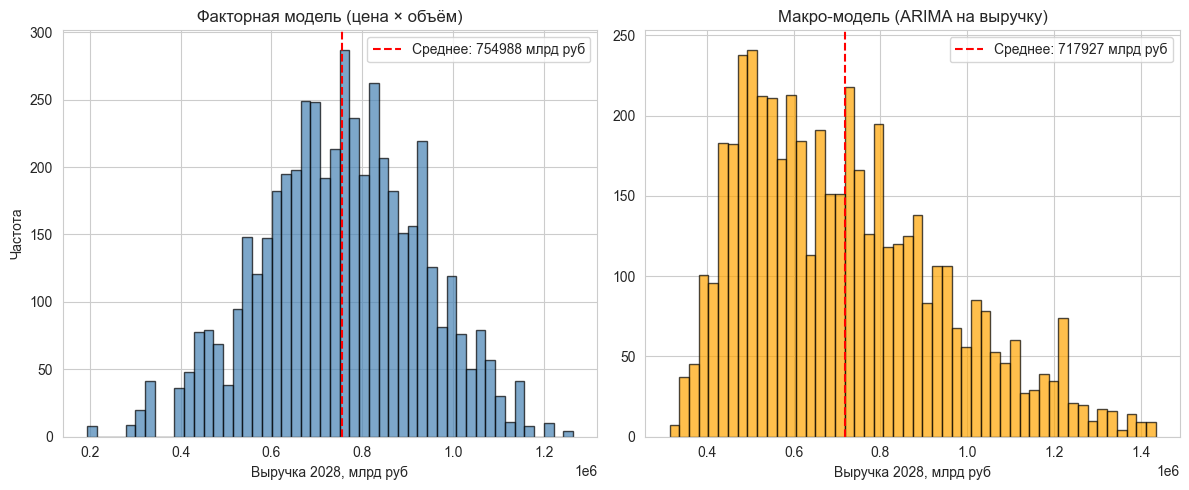

=== Риск-метрики факторной модели для Северстали (2028) ===
Ожидаемая выручка: 754988 млрд руб
VaR 10%: 533364 млрд руб
CVaR 10%: 449177 млрд руб
Коэффициент вариации: 0.23

=== Старая макро-модель ===
Ожидаемая выручка: 717927 млрд руб
VaR 10%: 452953 млрд руб
CVaR 10%: 411455 млрд руб
Коэффициент вариации: 0.32

✅ Блок 5 выполнен. Факторная модель построена.


In [ ]:
# %% [markdown]
# # БЛОК 5 — ФАКТОРНОЕ МОДЕЛИРОВАНИЕ ДЛЯ СЕВЕРСТАЛИ (ЦЕНА × ОБЪЁМ)
# 
# **Важно:** предполагается, что блоки 1–4 уже выполнены (импорт, загрузка макро, генерация сценариев).
# Если вы запускаете блок 5 изолированно, сначала выполните блок 1.

# %%
# 5.1 — Загрузка операционных данных Северстали из Excel
OPER_PATH = 'severstal_operational.xlsx'
severstal_oper = pd.read_excel(OPER_PATH, sheet_name=0, engine='openpyxl')
severstal_oper['Year'] = severstal_oper['Year'].astype(int)
print(f"Операционные данные: {severstal_oper.shape}")

# %%
# 5.2 — Расчёт недостающих колонок
severstal_oper['steel_sales_commercial_mmt'] = (
    severstal_oper['steel_sales_total_mmt'] 
    - severstal_oper['steel_sales_higher_value_mmt'].fillna(0)
    - severstal_oper['steel_sales_semifinished_mmt'].fillna(0)
)

# %%
# 5.3 — Объединение с макро-данными
if 'macro_df' not in globals():
    macro_df = pd.read_excel('macro_annual.xlsx', sheet_name='annual', engine='openpyxl')
    macro_df = macro_df.astype({col: float for col in macro_df.columns if col != 'year'})

severstal_full = severstal_oper.merge(macro_df, left_on='Year', right_on='year', how='left')
severstal_full.drop(columns='year', inplace=True)

# %%
# 5.4 — Добавление финансовых показателей (только revenue_rub и ebitda_rub) из companies_annual
if 'companies_df' not in globals():
    companies_df = pd.read_excel('companies_annual.xlsx', sheet_name='Лист1', engine='openpyxl')
severstal_fin = companies_df[companies_df['company'] == 'CHMF'][['year', 'revenue_rub', 'ebitda_rub']].copy()
severstal_full = severstal_full.merge(severstal_fin, left_on='Year', right_on='year', how='left')
severstal_full.drop(columns='year', inplace=True)

# CAPEX используем из операционного файла (уже есть колонка capex_rub)
print("Итоговый датафрейм для моделирования:")
print(severstal_full[['Year', 'steel_sales_total_mmt', 'avg_steel_price_rub_per_ton', 
                      'capex_rub', 'revenue_rub', 'usd_rub_avg', 'brent_avg']].head())

# %%
# 5.5 — Модель цены стали (руб/т) от курса USD/RUB и цены Brent
price_data = severstal_full.dropna(subset=['avg_steel_price_rub_per_ton', 'usd_rub_avg', 'brent_avg'])
X_price = sm.add_constant(price_data[['usd_rub_avg', 'brent_avg']])
y_price = price_data['avg_steel_price_rub_per_ton']
model_price = sm.OLS(y_price, X_price).fit()
print(model_price.summary())

# %%
price_data['pred_price'] = model_price.predict(X_price)
plt.figure(figsize=(10,5))
plt.plot(price_data['Year'], price_data['avg_steel_price_rub_per_ton'], 'o-', label='Факт')
plt.plot(price_data['Year'], price_data['pred_price'], 's--', label='Модель')
plt.xlabel('Год')
plt.ylabel('Цена стали, руб/т')
plt.title('Модель цены стали (курс + Brent)')
plt.legend()
plt.grid(True)
plt.show()

# %%
# 5.6 — Модель объёма продаж стали (млн т) с лагом CAPEX, промпроизводством и экспортной долей
volume_data = severstal_full.dropna(subset=['steel_sales_total_mmt', 'capex_rub', 
                                            'industrial_production_growth', 'export_share_actual'])
volume_data = volume_data.copy()
volume_data['capex_lag1'] = volume_data['capex_rub'].shift(1)
volume_data = volume_data.dropna(subset=['capex_lag1'])

X_vol = sm.add_constant(volume_data[['capex_lag1', 'industrial_production_growth', 'export_share_actual']])
y_vol = volume_data['steel_sales_total_mmt']
model_vol = sm.OLS(y_vol, X_vol).fit()
print(model_vol.summary())

# %%
volume_data['pred_sales'] = model_vol.predict(X_vol)
plt.figure(figsize=(10,5))
plt.plot(volume_data['Year'], volume_data['steel_sales_total_mmt'], 'o-', label='Факт')
plt.plot(volume_data['Year'], volume_data['pred_sales'], 's--', label='Модель')
plt.xlabel('Год')
plt.ylabel('Продажи стали, млн т')
plt.title('Модель объёма продаж (CAPEX лаг, промпроизводство, экспортная доля)')
plt.legend()
plt.grid(True)
plt.show()

# %%
# 5.7 — Прогноз выручки через факторную модель с использованием макро-сценариев
last_capex = severstal_full[severstal_full['Year'] == 2025]['capex_rub'].values[0]
last_export_share = severstal_full[severstal_full['Year'] == 2025]['export_share_actual'].values[0] / 100.0

capex_forecast = last_capex
export_share_forecast = last_export_share

# Доля прочей выручки
severstal_full['other_revenue_share'] = (severstal_full['revenue_rub'] - 
                                         severstal_full['avg_steel_price_rub_per_ton'] * severstal_full['steel_sales_total_mmt']/1000) / severstal_full['revenue_rub']
other_share_mean = severstal_full['other_revenue_share'].mean()

def predict_revenue_factor(scenario_macro):
    n_years = scenario_macro.shape[0]
    revenues = []
    for t in range(n_years):
        usd = scenario_macro[t, macro_cols.index('usd_rub_avg')]
        brent = scenario_macro[t, macro_cols.index('brent_avg')]
        ind_prod = scenario_macro[t, macro_cols.index('industrial_production_growth')]
        
        X_price_t = np.array([1, usd, brent])
        price_rub = model_price.params.values @ X_price_t
        
        X_vol_t = np.array([1, capex_forecast, ind_prod, export_share_forecast*100])
        sales_mmt = model_vol.params.values @ X_vol_t
        
        steel_revenue = price_rub * sales_mmt / 1000
        total_revenue = steel_revenue / (1 - other_share_mean) if other_share_mean < 1 else steel_revenue
        revenues.append(total_revenue)
    return np.array(revenues)

if 'scenarios' not in globals():
    raise NameError("Переменная 'scenarios' не найдена. Выполните блок 3 (генерация сценариев).")
if 'macro_cols' not in globals():
    macro_cols = ['gdp_growth', 'inflation_cpi', 'key_rate_avg', 'usd_rub_avg',
                  'urals_avg', 'brent_avg', 'unemployment_avg', 'retail_sales_growth',
                  'industrial_production_growth']

n_sim, n_years, _ = scenarios.shape
revenues_factor = np.zeros((n_sim, n_years))
for i in range(n_sim):
    revenues_factor[i, :] = predict_revenue_factor(scenarios[i, :, :])
print(f"Прогноз выручки (факторная модель): {revenues_factor.shape}")

# %%
# 5.8 — Сравнение с предыдущей макро-моделью (если доступна)
if 'predictions' in globals() and 'CHMF' in predictions:
    revenues_old = predictions['CHMF']
else:
    revenues_old = None

fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].hist(revenues_factor[:, 2], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax[0].axvline(revenues_factor[:, 2].mean(), color='red', linestyle='--', label=f'Среднее: {revenues_factor[:, 2].mean():.0f} млрд руб')
ax[0].set_title('Факторная модель (цена × объём)')
ax[0].set_xlabel('Выручка 2028, млрд руб')
ax[0].set_ylabel('Частота')
ax[0].legend()
if revenues_old is not None:
    ax[1].hist(revenues_old[:, 2], bins=50, alpha=0.7, color='orange', edgecolor='black')
    ax[1].axvline(revenues_old[:, 2].mean(), color='red', linestyle='--', label=f'Среднее: {revenues_old[:, 2].mean():.0f} млрд руб')
    ax[1].set_title('Макро-модель (ARIMA на выручку)')
    ax[1].set_xlabel('Выручка 2028, млрд руб')
    ax[1].legend()
else:
    ax[1].text(0.5, 0.5, 'Старая модель не найдена', ha='center', transform=ax[1].transAxes)
plt.tight_layout()
plt.show()

# %%
mean_2028 = revenues_factor[:, 2].mean()
var10 = np.percentile(revenues_factor[:, 2], 10)
cvar10 = revenues_factor[:, 2][revenues_factor[:, 2] <= var10].mean()
cv = revenues_factor[:, 2].std() / mean_2028

print("=== Риск-метрики факторной модели для Северстали (2028) ===")
print(f"Ожидаемая выручка: {mean_2028:.0f} млрд руб")
print(f"VaR 10%: {var10:.0f} млрд руб")
print(f"CVaR 10%: {cvar10:.0f} млрд руб")
print(f"Коэффициент вариации: {cv:.2f}")

if revenues_old is not None:
    mean_old = revenues_old[:, 2].mean()
    var_old = np.percentile(revenues_old[:, 2], 10)
    cvar_old = revenues_old[:, 2][revenues_old[:, 2] <= var_old].mean()
    cv_old = revenues_old[:, 2].std() / mean_old
    print("\n=== Старая макро-модель ===")
    print(f"Ожидаемая выручка: {mean_old:.0f} млрд руб")
    print(f"VaR 10%: {var_old:.0f} млрд руб")
    print(f"CVaR 10%: {cvar_old:.0f} млрд руб")
    print(f"Коэффициент вариации: {cv_old:.2f}")